### Numpy를 Image로 변환하기

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# numpy data 불러오기
import numpy as np

fruits = np.load("/kaggle/input/data-fruits/fruits.npy")
fruits.shape

(300, 100, 100)

In [6]:
fruits[0,0,:]

array([  1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   4,   3,   2,   1,   0,   0,   0,
         0,   6,   1,   0,   4,   3,   0,   1,   8,  14,   0,   0,   4,
         8,  13,  13, 156, 191, 116,  30,   3,   0,   0,   3,   6,   2,
         1,   0,   0,   0,   0,   1,   4,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1], dtype=int32)

In [7]:
# Image로 저장하기
from PIL import Image

In [15]:
# 폴더 만들기
import os

os.mkdir("Data")

In [16]:
# image 확인
image = Image.fromarray(fruits[200]).convert('L')
image.save("./Data/fruits200.jpg", "JPEG")

In [17]:
for i in range(300):
    image = Image.fromarray(fruits[i]).convert('L')
    image.save("./Data/fruits_%03d.jpg"%i, "JPEG")

### Image를 읽어서 Numpy로 변환하기

In [18]:
import glob

In [19]:
numberOfData = 300 # 데이터 수
imgSize = 100 # 이미지 사이즈

In [21]:
# 배열 초기화 
fruitsData = \
    np.zeros(numberOfData*imgSize*imgSize, dtype=np.int32).reshape(numberOfData, imgSize, imgSize)
fruitsData

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [23]:
i = 0

for file in sorted(glob.glob("./Data/fruits_*.jpg")):
    img = np.array(Image.open(file), dtype=np.int32)
    fruitsData[i,:,:] = img
    i += 1

In [24]:
fruitsData.shape

(300, 100, 100)

In [25]:
# 이미지 확인
import matplotlib.pyplot as plt

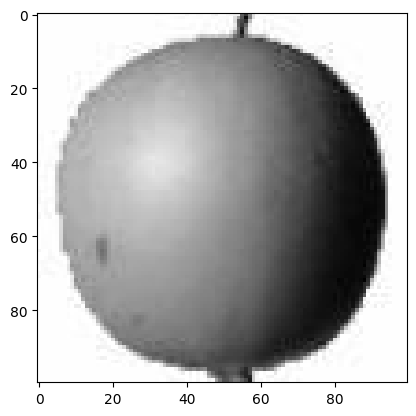

In [26]:
plt.imshow(fruitsData[0], cmap='gray_r')
plt.show()

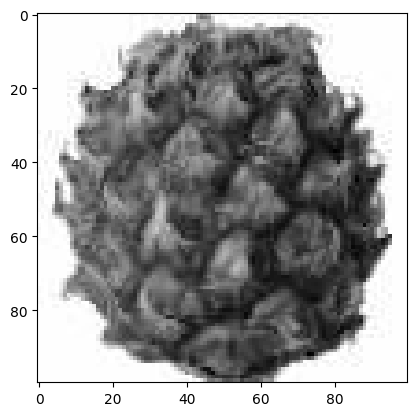

In [27]:
plt.imshow(fruitsData[100], cmap='gray_r')
plt.show()

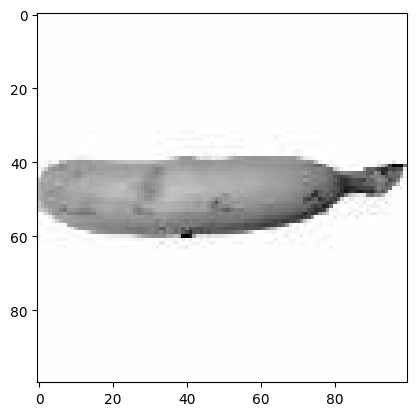

In [28]:
plt.imshow(fruitsData[200], cmap='gray_r')
plt.show()

In [29]:
# Numpy Image Data를 file로 저장하기
np.save("./fruitsData", fruitsData)